In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
from tensorflow.keras.callbacks import EarlyStopping
import streamlit
import joblib


In [2]:
with_mask_path="face_mask_dataset/data/with_mask"
without_mask_path="face_mask_dataset/data/without_mask"
data=[]
labels=[]
IMG_SIZE=64
for img_name in os.listdir(with_mask_path):
    try:
        img_path=os.path.join(with_mask_path,img_name)
        img=cv2.imread(img_path)
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(0)
    except:
       pass
for img_name in os.listdir(without_mask_path):
    try:
        img_path=os.path.join(without_mask_path,img_name)
        img=cv2.imread(img_path)
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        data.append(img)
        labels.append(1)
    except:
        pass

data=np.array(data)
labels=np.array(labels)
print(data.shape)
print(labels.shape)


(7553, 64, 64, 3)
(7553,)


In [3]:
x=np.array(data,dtype="float32")/255.0
y=np.array(labels)
print(x.shape)
print(y.shape)


(7553, 64, 64, 3)
(7553,)


In [4]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=labels)
print("\n x_train_shape: ",x_train.shape)
print("\n x_test_shape: ",x_test.shape)


 x_train_shape:  (6042, 64, 64, 3)

 x_test_shape:  (1511, 64, 64, 3)


In [5]:
datagen=ImageDataGenerator(rotation_range=20,zoom_range=0.15,width_shift_range=0.1,height_shift_range=0.1,shear_range=0.15,horizontal_flip=True,fill_mode="nearest")

In [6]:
datagen.fit(x_train)

In [7]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation="relu",input_shape=(64,64,3))),
model.add(MaxPooling2D((2,2))),
model.add(Conv2D(64,(3,3),activation="relu")),
model.add(MaxPooling2D((2,2))),
model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2)),
model.add(Flatten()),
model.add(Dense(128,activation="relu")),
model.add(Dropout(0.5)),
model.add(Dense(1,activation="sigmoid")),

   
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 6, 6, 128)        0

In [8]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

In [9]:
early_stopping=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [10]:
history=model.fit(datagen.flow(x_train,y_train,batch_size=32),epochs=30,validation_data=(x_test,y_test),callbacks=[early_stopping])

Epoch 1/30
189/189 [==============================] - 12s 42ms/step - loss: 0.3939 - accuracy: 0.8259 - val_loss: 0.2618 - val_accuracy: 0.8994
Epoch 2/30
189/189 [==============================] - 7s 39ms/step - loss: 0.2689 - accuracy: 0.8888 - val_loss: 0.1807 - val_accuracy: 0.9292
Epoch 3/30
189/189 [==============================] - 7s 37ms/step - loss: 0.2235 - accuracy: 0.9176 - val_loss: 0.1450 - val_accuracy: 0.9504
Epoch 4/30
189/189 [==============================] - 8s 40ms/step - loss: 0.2066 - accuracy: 0.9232 - val_loss: 0.1531 - val_accuracy: 0.9530
Epoch 5/30
189/189 [==============================] - 7s 37ms/step - loss: 0.1893 - accuracy: 0.9343 - val_loss: 0.1709 - val_accuracy: 0.9385
Epoch 6/30
189/189 [==============================] - 7s 35ms/step - loss: 0.1751 - accuracy: 0.9383 - val_loss: 0.1177 - val_accuracy: 0.9629
Epoch 7/30
189/189 [==============================] - 7s 36ms/step - loss: 0.1707 - accuracy: 0.9363 - val_loss: 0.1230 - val_accuracy: 0.957

In [11]:
loss,accuracy=model.evaluate(x_test,y_test)
print("Accuracy:- ",accuracy)
print("Loss:- ",loss)

48/48 [==============================] - 0s 6ms/step - loss: 0.0734 - accuracy: 0.9788
Accuracy:-  0.9788219928741455
Loss:-  0.07339825481176376


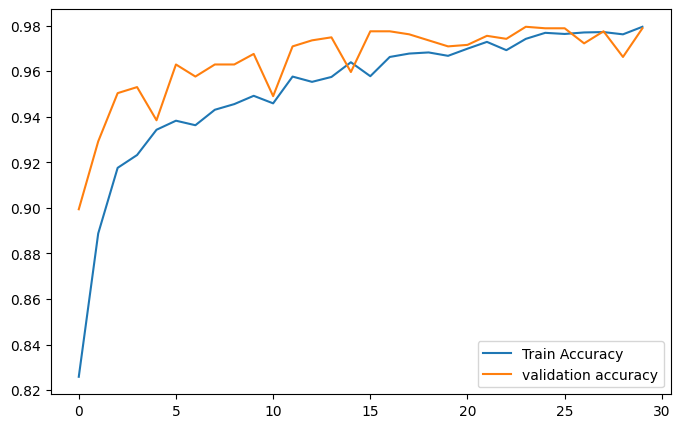

In [12]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Train Accuracy")
plt.plot(history.history["val_accuracy"],label="validation accuracy")
plt.legend()
plt.legend()
plt.show()

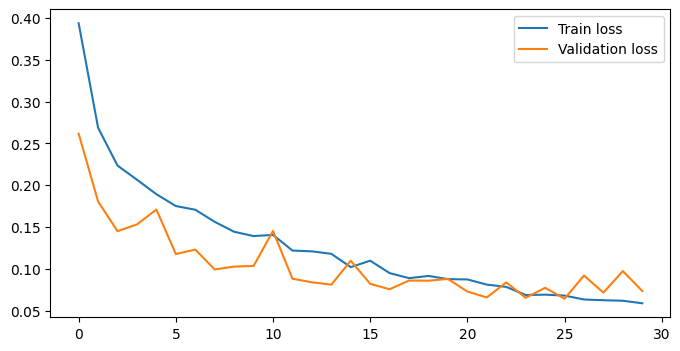

In [13]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"],label="Train loss")
plt.plot(history.history["val_loss"],label="Validation loss")
plt.legend()
plt.show()

In [14]:
y_pred=model.predict(x_test)
y_pred=(y_pred>0.5).astype(int).flatten()

48/48 [==============================] - 0s 4ms/step


In [15]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
auc=roc_auc_score(y_test,y_pred)
print("Accuracy score:- ",accuracy)
print("Precision score:- ",precision)
print("Recall score:- ",recall)
print("f1_score:- ",f1)
print("auc_roc_score:- ",auc)

Accuracy score:-  0.9788219722038385
Precision score:-  0.9919571045576407
Recall score:-  0.9660574412532638
f1_score:-  0.978835978835979
auc_roc_score:-  0.9790018749890481


In [16]:
class_report=classification_report(y_test,y_pred)
print("Classification report:- ",class_report)

Classification report:-                precision    recall  f1-score   support

           0       0.97      0.99      0.98       745
           1       0.99      0.97      0.98       766

    accuracy                           0.98      1511
   macro avg       0.98      0.98      0.98      1511
weighted avg       0.98      0.98      0.98      1511



In [17]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion matrix:- ",cm)

Confusion matrix:-  [[739   6]
 [ 26 740]]


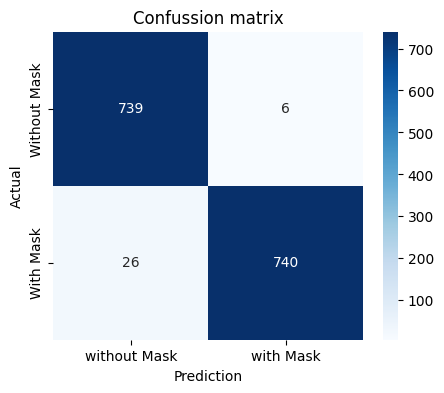

In [18]:
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,cmap="Blues",fmt="d",xticklabels=["without Mask","with Mask"],yticklabels=["Without Mask","With Mask"])
plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confussion matrix")
plt.show()

In [19]:
model.save("face_mask_model.h5")

In [28]:
%%writefile app_7.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
model=tf.keras.models.load_model("face_mask_model.h5")
st.title("Face Mask Detection")
uploaded_file=st.file_uploader("Uploadn Image",type=["jpg","png","jpeg"])
if uploaded_file is not None:
    image=Image.open(uploaded_file)
    st.image(image,caption="Uploaded Image")
    img=image.resize((64,64))
    img=np.array(img)
    img=img[:,:,::-1]
    img=img.astype("float32")/255.0
    img=np.expand_dims(img,axis=0)
    prediction=model.predict(img)
    score=prediction[0][0]
    st.write("Prediction Score ",score)
    if score>0.5:
        st.success("Not Mask Detected")
    else:
        st.error("Mask Detected")
    

Overwriting app_7.py


In [29]:
%%writefile requirements.txt
streamlit
pandas
numpy
sckit-learn
tensorflow
pillow
opencv-pyhon-headless

Overwriting requirements.txt
